In [1]:
from jma_data_tools import AmedasData
# Test: Get stations in a latitude and longitude range
lat_min, lat_max = 35.5, 37.0
lon_min, lon_max = 139.5, 141.0
print(f"Stations in the specified latitude and longitude range:")
stations_in_range = AmedasData.get_stations_by_location_range(lat_min, lat_max, lon_min, lon_max)
for station_id, info in stations_in_range.items():
    print(f"Station ID: {station_id}, Name: {info['station_name']}")

Stations in the specified latitude and longitude range:
Station ID: 312, Name: 東白川
Station ID: 47598, Name: 小名浜
Station ID: 1607, Name: 山田
Station ID: 314, Name: 花園
Station ID: 315, Name: 北茨城
Station ID: 316, Name: 大子
Station ID: 317, Name: 神峰山
Station ID: 318, Name: 笠間
Station ID: 47629, Name: 水戸
Station ID: 320, Name: 古河
Station ID: 321, Name: 愛宕山
Station ID: 322, Name: 下妻
Station ID: 323, Name: 坂東
Station ID: 324, Name: 土浦
Station ID: 325, Name: 鹿嶋
Station ID: 911, Name: 江戸崎
Station ID: 1011, Name: 日立
Station ID: 1012, Name: 柿岡
Station ID: 1013, Name: 美野里
Station ID: 1014, Name: 龍ケ崎
Station ID: 1082, Name: 筑波山
Station ID: 1170, Name: 中野
Station ID: 1173, Name: 徳田
Station ID: 1245, Name: 鉾田
Station ID: 1331, Name: 常陸大宮
Station ID: 1388, Name: 門井
Station ID: 1421, Name: 大能
Station ID: 47646, Name: つくば(館野)
Station ID: 1530, Name: 下館
Station ID: 1635, Name: 高萩
Station ID: 328, Name: 八方が原
Station ID: 329, Name: 黒磯
Station ID: 330, Name: 八溝山
Station ID: 331, Name: 大田原
Station ID: 47690, N

In [4]:
import pandas as pd

In [2]:

from jma_data_tools import JMAGroundDataDownloader
import time
import os

# Initialize the downloader
downloader = JMAGroundDataDownloader( output_path= 'ground_data' )

# Set up parameters
for point in [ '47646', '47662'][:0]:  # Tsukuba & Tokyo station
    output_dir = "daily_data"  # Directory to save daily data files
    start_date = pd.Timestamp('1960-01-01')
    end_date = pd.Timestamp('2024-03-01')
    
    # Generate date range for 30 years of daily data
    date_range = pd.date_range(start=start_date, end=end_date, freq='MS')
    # Loop over each date to download daily data
    for date in date_range:
        print(f"Downloading data for {date.strftime('%Y-%m-%d')}...")
        # Download the daily data for the specified point and date
        daily_data = downloader.download_amedas(point, date, dtype='daily')
        time.sleep(0.5)
    print("Download complete.")

In [2]:
from jma_data_tools import AmedasData
stids = sorted([ sti for sti in AmedasData.data.keys() if sti > 40000])
print(stids[:])

[47401, 47402, 47404, 47405, 47406, 47407, 47409, 47411, 47412, 47413, 47417, 47418, 47420, 47421, 47423, 47424, 47426, 47428, 47430, 47433, 47435, 47440, 47512, 47520, 47570, 47574, 47575, 47576, 47581, 47582, 47584, 47585, 47587, 47588, 47590, 47592, 47595, 47597, 47598, 47600, 47602, 47604, 47605, 47606, 47607, 47610, 47612, 47615, 47616, 47617, 47618, 47620, 47622, 47624, 47626, 47629, 47631, 47632, 47636, 47637, 47638, 47639, 47640, 47641, 47646, 47648, 47649, 47651, 47653, 47654, 47655, 47656, 47657, 47662, 47663, 47666, 47668, 47670, 47672, 47674, 47675, 47677, 47678, 47682, 47684, 47690, 47740, 47741, 47742, 47744, 47746, 47747, 47750, 47751, 47754, 47755, 47756, 47759, 47761, 47762, 47765, 47766, 47767, 47768, 47769, 47770, 47772, 47776, 47777, 47778, 47780, 47784, 47800, 47805, 47807, 47809, 47812, 47813, 47814, 47815, 47817, 47818, 47819, 47821, 47822, 47823, 47824, 47827, 47829, 47830, 47831, 47835, 47836, 47837, 47838, 47843, 47887, 47890, 47891, 47892, 47893, 47894, 47895

In [5]:
df_stations = pd.DataFrame([ AmedasData.data[sti] for sti in AmedasData.data.keys() if sti > 40000], index=[ sti for sti in AmedasData.data.keys() if sti > 40000])
df_stations.to_csv('list_of_stations.csv')

'\nnorm = mcolors.Normalize(vmin=min(point_values), vmax=max(point_values))\ncolor_map = cm.hot\nsc = ax.scatter(longitude, latitude, c=point_values, cmap=color_map, s=20, norm=norm, transform=ccrs.PlateCarree())\n\n#==========\n# Create the colorbar and place it inside the map\nsm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)\nsm.set_array([])  \n# Add the colorbar to the figure with custom placement and appearance\ncbar = fig.colorbar(sm, ax=ax, orientation=\'horizontal\',\n                    pad=0.05, fraction=0.05, shrink=0.5, anchor=(0.8, 0.5))\n\n# Set the label for the colorbar\ncbar.set_label("Temperature ($^oC$)")\n'

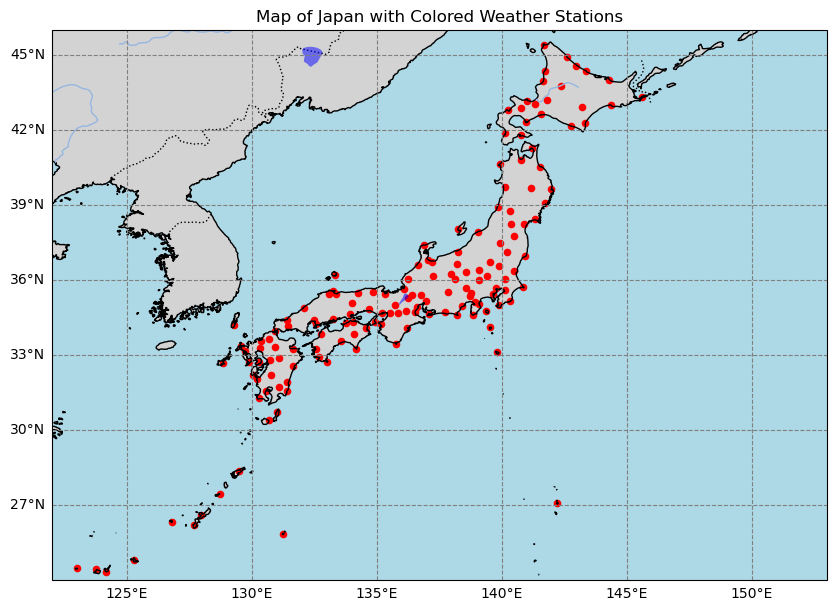

In [6]:
import matplotlib.pyplot as plt
# Import the Cartopy library for geographic projections
import cartopy.crs as ccrs
# Import Cartopy's feature module to add map features like coastlines and borders
import cartopy.feature as cfeature

map_extent = [122, 153, 24, 46]
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(map_extent, crs=ccrs.PlateCarree())
# Add coastlines and other features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, facecolor='blue', alpha=0.5)
ax.add_feature(cfeature.RIVERS)
# Optional gridlines
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
plt.title("Map of Japan with Colored Weather Stations")

longitude, latitude = df_stations.longitude, df_stations.latitude
sc = ax.scatter(longitude, latitude, c='red', s=20, transform=ccrs.PlateCarree())

'''
norm = mcolors.Normalize(vmin=min(point_values), vmax=max(point_values))
color_map = cm.hot
sc = ax.scatter(longitude, latitude, c=point_values, cmap=color_map, s=20, norm=norm, transform=ccrs.PlateCarree())

#==========
# Create the colorbar and place it inside the map
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])  
# Add the colorbar to the figure with custom placement and appearance
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                    pad=0.05, fraction=0.05, shrink=0.5, anchor=(0.8, 0.5))

# Set the label for the colorbar
cbar.set_label("Temperature ($^oC$)")
'''



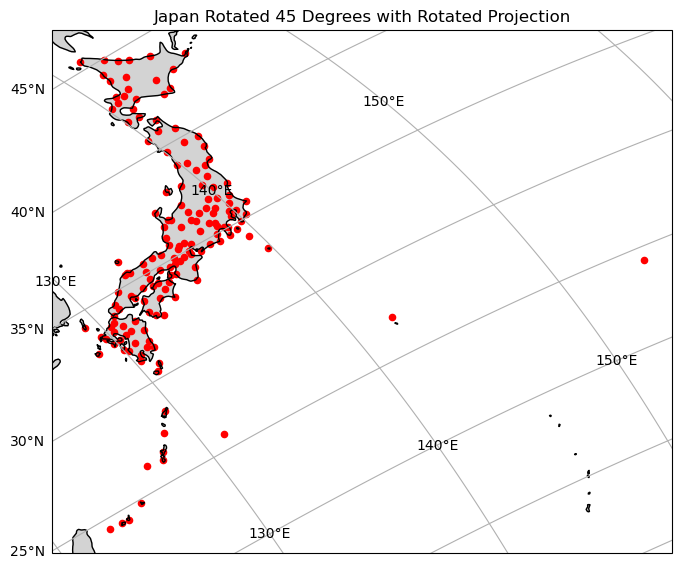

In [46]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define a rotated projection
rotated_projection = ccrs.RotatedPole(
    pole_longitude=200,  # Shift the pole longitude
    pole_latitude=60     # Rotate the pole latitude by 45 degrees
)

# Create a figure with the rotated projection
fig, ax = plt.subplots(subplot_kw={'projection': rotated_projection}, figsize=(8, 8))

# Add features to the map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Set the extent to focus on Japan in the rotated view
#ax.set_extent([120, 150, 20, 50], crs=ccrs.PlateCarree())

# Add gridlines for context
gl = ax.gridlines(draw_labels=True)
gl.right_labels = False
gl.top_labels = False

# Title for clarity
ax.set_title("Japan Rotated 45 Degrees with Rotated Projection")
longitude, latitude = df_stations.longitude, df_stations.latitude
sc = ax.scatter(longitude, latitude, c='red', s=20, transform=ccrs.PlateCarree())
plt.show()


In [7]:
df_stations

,station_name,station_name_kana,station_name_roman,fuken_id,type,longitude,latitude,height
47401,稚内,ワツカナイ,Watsukanai,11,S,141.678333,45.415000,2.8
47402,北見枝幸,キタミエサシ,Kitamiesashi,11,S,142.585000,44.940000,6.7
47407,旭川,アサヒカワ,Asahikawa,12,S,142.371667,43.756667,120.0
47404,羽幌,ハボロ,Haboro,13,S,141.700000,44.363333,7.9
47406,留萌,ルモイ,Rumoi,13,S,141.631667,43.945000,23.6
...,...,...,...,...,...,...,...,...
47927,宮古島,ミヤコジマ,Miyakojima,91,S,125.276667,24.793333,39.9
47929,久米島,クメジマ,Kumejima,91,S,126.803333,26.336667,5.0
47917,西表島,イリオモテジマ,Iriomotejima,91,S,123.765000,24.426667,9.9
47912,与那国島,ヨナグニジマ,Yonagunijima,91,S,123.010000,24.466667,30.0


In [10]:
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# Extract relevant columns: station ID, latitude, and longitude
stations_df = df_stations

# Define a function to calculate the haversine distance
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    # Radius of Earth in kilometers (mean radius)
    R = 6371.0
    return R * c

# Create an adjacency matrix to store distances
station_ids = stations_df.index.values
num_stations = len(station_ids)
adj_matrix = np.zeros((num_stations, num_stations))

# Calculate distances between all pairs of stations
for i in range(num_stations)[:]:
    for j in range(num_stations)[:]:
        if i != j:  # No need to calculate distance for the same station
            adj_matrix[i, j] = haversine(
                stations_df.iloc[i]["latitude"],
                stations_df.iloc[i]["longitude"],
                stations_df.iloc[j]["latitude"],
                stations_df.iloc[j]["longitude"]
            )

# Convert adjacency matrix to a DataFrame for better readability
adj_matrix_df = pd.DataFrame(adj_matrix, index=station_ids, columns=station_ids)

# Save the adjacency matrix to a CSV file and display it
output_path = 'station_distance_matrix.csv'
adj_matrix_df.to_csv(output_path)
output_path


'station_distance_matrix.csv'

In [11]:
adj_matrix_df

,47401,47402,47407,47404,47406,47412,47413,47411,47433,47421,...,47836,47942,47940,47936,47918,47927,47929,47917,47912,47945
47401,0.000000,88.544042,192.397161,116.952453,163.498171,263.343556,245.146365,253.854131,289.153325,313.625320,...,1926.597220,2305.353767,2421.505953,2472.442413,2822.839066,2723.781207,2500.043581,2834.217258,2869.289675,2369.137394
47402,88.544042,0.000000,132.669467,94.933476,134.045908,231.949209,202.526206,232.220782,269.982403,304.489397,...,1924.432482,2303.820563,2420.804576,2471.915115,2829.479112,2728.050082,2502.591240,2842.138829,2879.363706,2355.923567
47407,192.397161,132.669467,0.000000,86.203179,62.925592,114.471767,76.894287,126.665513,161.669452,204.154872,...,1809.980940,2189.379411,2306.893788,2358.091853,2721.324039,2617.923976,2391.227951,2735.119135,2774.290138,2233.398177
47404,116.952453,94.933476,86.203179,0.000000,46.834899,147.970290,128.241113,142.389229,179.552360,211.085856,...,1831.332169,2210.644295,2327.472040,2378.553559,2735.038184,2633.900617,2408.682378,2747.566378,2784.616473,2266.060253
47406,163.498171,134.045908,62.925592,46.834899,0.000000,101.402864,82.473048,98.283881,135.997418,171.198384,...,1790.483879,2169.888233,2286.924607,2338.045848,2696.591078,2594.740282,2369.049233,2709.524427,2747.271747,2222.492038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47927,2723.781207,2728.050082,2617.923976,2633.900617,2594.740282,2504.074657,2541.196833,2497.914536,2460.345884,2423.649732,...,816.965260,450.771305,335.573618,288.294474,123.512466,0.000000,229.997353,158.165101,231.969052,609.006746
47929,2500.043581,2502.591240,2391.227951,2408.682378,2369.049233,2277.591343,2314.429266,2271.930194,2234.294155,2198.106108,...,587.196938,224.484479,119.104536,89.090526,346.173739,229.997353,0.000000,371.828737,434.030444,445.340898
47917,2834.217258,2842.138829,2735.119135,2747.566378,2709.524427,2620.870946,2658.667383,2613.509572,2576.151349,2538.331700,...,949.279598,596.296000,485.434071,440.903273,41.565152,158.165101,371.828737,0.000000,76.554816,767.055330
47912,2869.289675,2879.363706,2774.290138,2784.616473,2747.271747,2659.898251,2698.067587,2651.824354,2614.625704,2576.172722,...,1000.906991,657.839271,550.477685,508.061104,117.679734,231.969052,434.030444,76.554816,0.000000,840.640219


In [7]:
import pandas as pd
from jma_data_tools import JMAGroundDataDownloader
import time
import os

# Initialize the downloader
downloader = JMAGroundDataDownloader( output_path= 'ground_data' )

# Set up parameters
for point_int in stids[:0]:  
    point = str(point_int)
    print('=== \n Download station: ',point, '\n===')
    output_dir = "daily_data"  # Directory to save daily data files
    start_date = pd.Timestamp('1950-01-01')
    end_date = pd.Timestamp('2024-03-01')
    
    # Generate date range for 30 years of daily data
    date_range = pd.date_range(start=start_date, end=end_date, freq='MS')
    # Loop over each date to download daily data
    for date in date_range[:]:
        print(f"Downloading data for {date.strftime('%Y-%m-%d')}...")
        # Download the daily data for the specified point and date
        daily_data = downloader.download_amedas(point, date, dtype='daily')
        time.sleep(0.3)
    print("Download complete.")